# Preprocesamiento y Análisis Exploratorio de Imágenes MRI de Tumores Cerebrales
En este notebook se realiza la carga, preprocesamiento y análisis exploratorio del dataset de imágenes MRI para clasificación de tumores cerebrales.

---

**Flujo del notebook:**
1. Importación de librerías
2. Configuración de rutas y descarga de datos
3. Reorganización y verificación de la estructura de carpetas
4. Visualización de imágenes de ejemplo
5. Preprocesamiento y guardado de imágenes
6. Preparación de arrays de datos y etiquetas
7. Visualización de la distribución de clases

Cada sección está documentada para facilitar la revisión y comprensión del proceso por parte del profesor.

## 1. Librerías necesarias

In [ ]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
import shutil
import cv2

## 2. Configuración de rutas y descarga de datos
Se definen las rutas principales del proyecto y se descarga el dataset desde Kaggle si no está presente en el entorno local.

## 2. Configuración de rutas y entorno local

In [ ]:
PROJECT_ROOT = str(Path.cwd().parent)

ROOT_DATA_PATH = os.path.join(PROJECT_ROOT, 'data/')
ORIGINAL_PATH = os.path.join(ROOT_DATA_PATH, 'original')
DATASET_PATH = os.path.join(ORIGINAL_PATH, 'brain-cancer-mri-dataset/')
KAGGLE_PATH = str(Path.home() / '.kaggle')

data_root = os.path.join(PROJECT_ROOT, 'data')
data_original = os.path.join(data_root, 'original')
data_preproc = os.path.join(data_root, 'preprocesadas')
for carpeta in [data_root, data_original, data_preproc]:
    if not os.path.exists(carpeta):
        os.makedirs(carpeta, exist_ok=True)
        print(f'[INFO] Carpeta creada: {carpeta}')
    else:
        print(f'[INFO] Carpeta ya existe: {carpeta}')

if not os.path.exists(DATASET_PATH):
    print(f"Descargando dataset desde Kaggle a: {ORIGINAL_PATH}")
    if not os.path.exists(KAGGLE_PATH):
        os.makedirs(KAGGLE_PATH, exist_ok=True)
    print(f"Coloca tu archivo kaggle.json en: {KAGGLE_PATH}")
    os.makedirs(ORIGINAL_PATH, exist_ok=True)
    kaggle_cmd = (
        f"kaggle datasets download -d orvile/brain-cancer-mri-dataset -p {ORIGINAL_PATH} --unzip"
    )
    print(f"Ejecutando: {kaggle_cmd}")
    os.system(kaggle_cmd)
    print("¡Descarga y extracción completadas!")
else:
    print(f"El dataset ya está disponible en: {DATASET_PATH}")

[INFO] Carpeta ya existe: d:\Proyectos_programación\mriTumorClassifier\data
[INFO] Carpeta ya existe: d:\Proyectos_programación\mriTumorClassifier\data\original
[INFO] Carpeta ya existe: d:\Proyectos_programación\mriTumorClassifier\data\preprocesadas
Descargando dataset desde Kaggle a: d:\Proyectos_programación\mriTumorClassifier\data/original
Coloca tu archivo kaggle.json en: C:\Users\Andres\.kaggle
Ejecutando: kaggle datasets download -d orvile/brain-cancer-mri-dataset -p d:\Proyectos_programación\mriTumorClassifier\data/original --unzip
¡Descarga y extracción completadas!
¡Descarga y extracción completadas!


## 3. Reorganización y verificación de la estructura de carpetas
Se reorganizan las carpetas de clases para asegurar una estructura uniforme y se eliminan carpetas vacías o innecesarias.

In [ ]:
CLASES_OBJETIVO = ['brain_glioma', 'brain_menin', 'brain_tumor']
root_original = os.path.join(ROOT_DATA_PATH, 'original')
for root, dirs, files in os.walk(root_original):
    for clase in CLASES_OBJETIVO:
        if clase in dirs:
            origen = os.path.join(root, clase)
            destino = os.path.join(root_original, clase)
            if origen != destino:
                print(f"Moviendo {origen} -> {destino}")
                if os.path.exists(destino):
                    print(f"[ADVERTENCIA] Ya existe {destino}, omitiendo...")
                else:
                    shutil.move(origen, destino)

def eliminar_vacias(path):
    for dirpath, dirnames, filenames in os.walk(path, topdown=False):
        if dirpath == path:
            continue
        if not dirnames and not filenames:
            print(f"Eliminando carpeta vacía: {dirpath}")
            os.rmdir(dirpath)

eliminar_vacias(root_original)

dataset_raw = os.path.join(root_original, 'Brain_Cancer raw MRI data')
if os.path.exists(dataset_raw):
    try:
        shutil.rmtree(dataset_raw)
        print(f"Carpeta '{dataset_raw}' eliminada.")
    except Exception as e:
        print(f"No se pudo eliminar '{dataset_raw}': {e}")

print("Estructura simplificada. Ahora las carpetas de clase están directamente en 'data/original'.")


Moviendo d:\Proyectos_programación\mriTumorClassifier\data/original\Brain_Cancer raw MRI data\Brain_Cancer\brain_glioma -> d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma
[ADVERTENCIA] Ya existe d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma, omitiendo...
Moviendo d:\Proyectos_programación\mriTumorClassifier\data/original\Brain_Cancer raw MRI data\Brain_Cancer\brain_menin -> d:\Proyectos_programación\mriTumorClassifier\data/original\brain_menin
[ADVERTENCIA] Ya existe d:\Proyectos_programación\mriTumorClassifier\data/original\brain_menin, omitiendo...
Moviendo d:\Proyectos_programación\mriTumorClassifier\data/original\Brain_Cancer raw MRI data\Brain_Cancer\brain_tumor -> d:\Proyectos_programación\mriTumorClassifier\data/original\brain_tumor
[ADVERTENCIA] Ya existe d:\Proyectos_programación\mriTumorClassifier\data/original\brain_tumor, omitiendo...
Carpeta 'd:\Proyectos_programación\mriTumorClassifier\data/original\Brain_Cancer raw MRI da

## 4. Verificación de integridad y conteo de imágenes
Se verifica que todas las carpetas de clase contengan imágenes y se realiza un conteo para asegurar la integridad del dataset.

## 3. Exploración de la estructura de carpetas y conteo de imágenes

In [ ]:
from collections import defaultdict

root_data = os.path.join(ROOT_DATA_PATH, 'original')
clases = ['brain_glioma', 'brain_menin', 'brain_tumor']
conteo_imagenes = defaultdict(int)
problemas = []

print('Verificando carpetas y conteo de imágenes por clase:')
for clase in clases:
    ruta_clase = os.path.join(root_data, clase)
    if not os.path.exists(ruta_clase):
        problemas.append(f"[ERROR] No existe la carpeta: {ruta_clase}")
        continue
    imagenes = glob(os.path.join(ruta_clase, '*.jpg'))
    conteo_imagenes[clase] = len(imagenes)
    print(f"  {clase}: {len(imagenes)} imágenes")
    if len(imagenes) == 0:
        problemas.append(f"[ERROR] No se encontraron imágenes en: {ruta_clase}")

if problemas:
    print("\nSe detectaron problemas de integridad:")
    for p in problemas:
        print(p)
    raise RuntimeError("Corrige los problemas de integridad antes de continuar.")
else:
    print("\nIntegridad de datos verificada. Todas las clases tienen imágenes disponibles.")

Verificando carpetas y conteo de imágenes por clase:
  brain_glioma: 2004 imágenes
  brain_menin: 2004 imágenes
  brain_tumor: 2048 imágenes

Integridad de datos verificada. Todas las clases tienen imágenes disponibles.


## 3.1 Verificación de integridad de datos
Antes de procesar, se verifica que existan imágenes en cada carpeta de clase y que las rutas sean correctas. Si alguna clase no tiene imágenes, se detalla el error y se detiene el flujo para evitar resultados vacíos o inconsistentes.

In [ ]:
root_data = os.path.join(ROOT_DATA_PATH, 'original')
clases = ['brain_glioma', 'brain_menin', 'brain_tumor']
print("Clases detectadas:", clases)

Clases detectadas: ['brain_glioma', 'brain_menin', 'brain_tumor']


## 5. Visualización de imágenes de ejemplo
Se muestran ejemplos de imágenes originales de cada clase para inspección visual y verificación de la calidad de los datos.

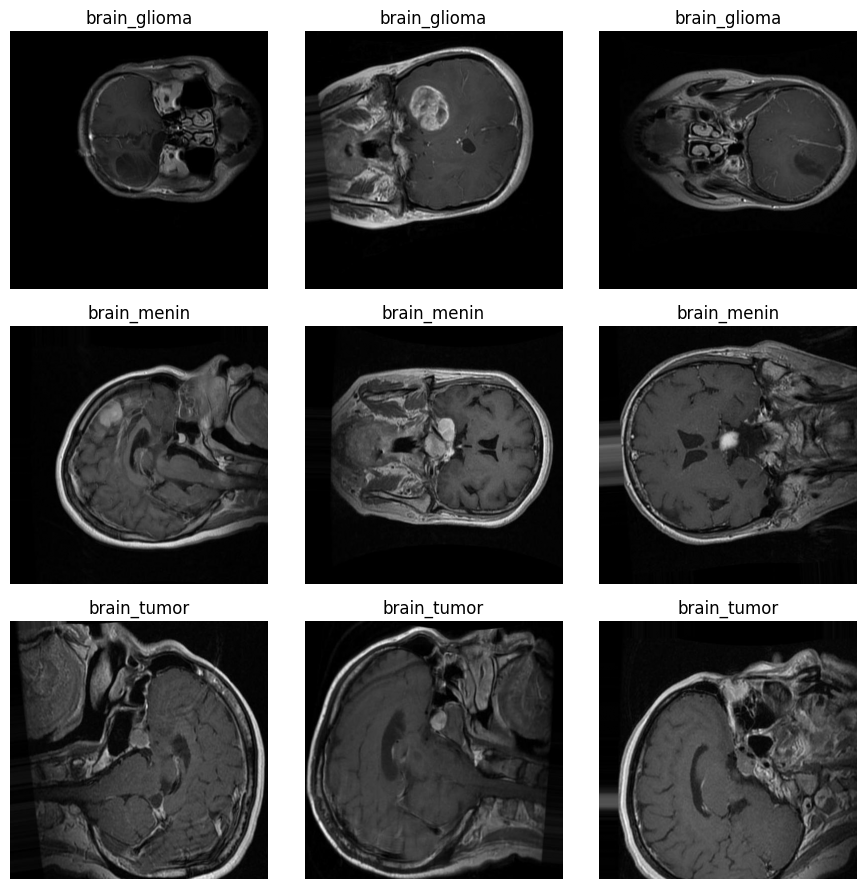

In [ ]:
def mostrar_ejemplos_originales(clases, n=3):
    ruta_base = os.path.join(ROOT_DATA_PATH, 'original')
    plt.figure(figsize=(n*3, len(clases)*3))
    for i, clase in enumerate(clases):
        ruta_clase = os.path.join(ruta_base, clase)
        imagenes = glob(os.path.join(ruta_clase, '*.jpg'))
        count = 0
        for img_path in imagenes:
            if count >= n:
                break
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                try:
                    with Image.open(img_path) as pil_img:
                        img = np.array(pil_img.convert('L'))
                except Exception as e:
                    print(f"[ADVERTENCIA] No se pudo cargar la imagen: {img_path} ({e})")
                    continue
            plt.subplot(len(clases), n, i*n + count + 1)
            plt.imshow(img, cmap='gray')
            plt.title(f'{clase}')
            plt.axis('off')
            count += 1
        if count == 0:
            print(f"[ADVERTENCIA] No se encontraron imágenes válidas para la clase: {clase}")
    plt.tight_layout()
    plt.show()

mostrar_ejemplos_originales(clases, n=3)

## 6. Preprocesamiento y guardado de imágenes
Se define la función de preprocesado, se aplica a las imágenes y se guardan los resultados en carpetas separadas para originales y preprocesadas.

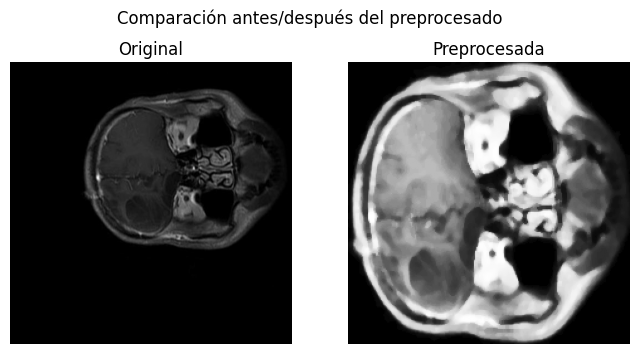

In [ ]:
def preprocesar_imagen(img_path, size=(224,224)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            with Image.open(img_path) as pil_img:
                pil_img = pil_img.convert('L')
                img = np.array(pil_img)
        except Exception as e:
            print(f"[ERROR] No se pudo cargar la imagen: {img_path} ({e})")
            return np.zeros(size)
    _, thresh = cv2.threshold(img, 5, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        img = img[y:y+h, x:x+w]
    img = cv2.resize(img, size)
    img = cv2.medianBlur(img, 5)
    img = cv2.equalizeHist(img)
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

imagenes_clase = glob(os.path.join(root_data, clases[0], '*.jpg'))
if not imagenes_clase:
    print(f'[ADVERTENCIA] No se encontraron imágenes en la clase: {clases[0]}')
else:
    img_path = imagenes_clase[0]
    img_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_orig is None:
        with Image.open(img_path) as pil_img:
            img_orig = np.array(pil_img.convert('L'))
    img_proc = preprocesar_imagen(img_path)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(img_orig, cmap='gray')
    plt.title('Original')
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(img_proc, cmap='gray')
    plt.title('Preprocesada')
    plt.axis('off')
    plt.suptitle('Comparación antes/después del preprocesado')
    plt.show()

In [ ]:
print('PROJECT_ROOT:', PROJECT_ROOT)
print('ROOT_DATA_PATH:', ROOT_DATA_PATH)
print('Carpeta preprocesadas (esperada):', os.path.join(ROOT_DATA_PATH, 'preprocesadas'))

if not os.path.exists(os.path.join(ROOT_DATA_PATH, 'preprocesadas')):
    print('[ADVERTENCIA] La carpeta preprocesadas no existe. Se creará.')
    os.makedirs(os.path.join(ROOT_DATA_PATH, 'preprocesadas'), exist_ok=True)

from PIL import Image as PILImage

total_guardadas = {}
for clase in clases:
    ruta_clase = os.path.join(root_data, clase)
    imgs = glob(os.path.join(ruta_clase, '*.jpg'))
    out_orig = os.path.join(ORIGINAL_PATH, clase)
    out_proc = os.path.join(ROOT_DATA_PATH, 'preprocesadas', clase)
    print(f'Ruta de guardado preprocesadas para {clase}:', out_proc)
    os.makedirs(out_orig, exist_ok=True)
    os.makedirs(out_proc, exist_ok=True)
    print(f'Procesando clase: {clase} ({len(imgs)} imágenes)')
    guardadas = 0
    for i, img_path in enumerate(imgs):
        nombre = os.path.basename(img_path)
        destino_orig = os.path.join(out_orig, nombre)
        if not os.path.exists(destino_orig):
            shutil.copy2(img_path, destino_orig)
        img_proc = preprocesar_imagen(img_path)
        if img_proc is not None and img_proc.sum() > 0:
            destino_proc = os.path.join(out_proc, nombre)
            img_uint8 = (img_proc * 255).clip(0,255).astype(np.uint8)
            try:
                PILImage.fromarray(img_uint8).save(destino_proc)
                if os.path.exists(destino_proc):
                    guardadas += 1
                else:
                    print(f'[ERROR] PIL no guardó la imagen: {destino_proc}')
            except Exception as e:
                print(f'[ERROR] PIL falló: {e} para {destino_proc}')
        else:
            print(f'[ADVERTENCIA] Imagen no procesada o vacía: {img_path}')
        if (i+1) % 100 == 0 or (i+1) == len(imgs):
            print(f'  {i+1}/{len(imgs)} imágenes procesadas')
    total_guardadas[clase] = guardadas
    print(f'  Total preprocesadas y guardadas para {clase}: {guardadas}')
print('Imágenes originales y preprocesadas guardadas en sus respectivas carpetas.')
print('Resumen por clase:', total_guardadas)

PROJECT_ROOT: d:\Proyectos_programación\mriTumorClassifier
ROOT_DATA_PATH: d:\Proyectos_programación\mriTumorClassifier\data/
Carpeta preprocesadas (esperada): d:\Proyectos_programación\mriTumorClassifier\data/preprocesadas
Ruta de guardado preprocesadas para brain_glioma: d:\Proyectos_programación\mriTumorClassifier\data/preprocesadas\brain_glioma
Procesando clase: brain_glioma (2004 imágenes)
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=19959.03125, dtype=float32, únicos=[0.         0.02745098 0.04313726 0.05098039 0.05882353]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain_glioma_0001.jpg
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=20180.595703125, dtype=float32, únicos=[0.         0.05098039 0.08627451 0.10588235 0.11372549]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain_glioma_0002.jpg
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=25590.974609375, dtype=float32, únicos=

[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=23305.837890625, dtype=float32, únicos=[0.         0.09803922 0.12941177 0.15294118 0.16862746]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain_glioma_1527.jpg
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=22311.73046875, dtype=float32, únicos=[0.         0.03921569 0.07450981 0.18039216 0.23529412]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain_glioma_1528.jpg
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=22979.8984375, dtype=float32, únicos=[0.         0.01960784 0.07843138 0.14509805 0.16470589]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain_glioma_1529.jpg
[DEPURACIÓN] img.shape=(224, 224), min=0.0, max=1.0, sum=25899.353515625, dtype=float32, únicos=[0.         0.03529412 0.14509805 0.25490198 0.30588236]... para d:\Proyectos_programación\mriTumorClassifier\data/original\brain_glioma\brain